# ORDER STATUS ANALYSIS

## BUSINESS CASE

1. Bagaimana distribusi order status (delivered, shipped, canceled, dll)?
2. Berapa rata-rata waktu dari order_purchase sampai order_approved per status?
3. Berapa persentase item yang dibatalkan dan kategori produk apa yang paling banyak mengalami pembatalan?


## IMPORT LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## GATHERING DATA

In [2]:
order = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/orders_dataset.csv')
order_items = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_items_dataset.csv')
product = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/products_dataset.csv')
name_translate_product = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/product_category_name_translation.csv')

## DATA UNDERSTANDING

In [3]:
order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
product.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### GRAIN

1. tabel order : 1 row merepresntasikan 1 order
2. tabel order_items : 1 row mempresentasikan item dalam sebuah order
3. tabel products : 1 row mempresentasikan 1 product

### KEY COLUMNS

1. **Tabel `orders`**:
   - `order_id` → identifier untuk setiap order
   - `order_status` → status order
   - `order_purchase_timestamp` → waktu saat customer melakukan order
   - `order_approved_at` → waktu saat order di approve

2. **Tabel `order_items`**:
   - `order_id` → identifier order, digunakan untuk menghubungkan `order_items` dengan `orders`
   - `order_item_id` → identifier order item id
   - `product_id` → identifier product, digunakan untuk menghubungkan `order_items` dengan `products`

3. **Tabel `products`**:
   - `product_id` → identifier untuk setiap product
   - `product_category_name` → kategori product

### RELATIONSHIP TABLE

- Tabel `orders` dan `order_items` terhubung melalui `order_id`.
- Tabel `order_items` dan `products` terhubung melalui `product_id`.

- `orders` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu order dapat memiliki beberapa item.
- `products` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu product dapat muncul pada beberapa order item.

## DATA QUALITY

### ASESSING DATA

In [6]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


1. Untuk kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` masih berbentuk object belum datetime

In [7]:
order.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [8]:
print('Checking null value')
order.isna().sum()

Checking null value


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

1.  Untuk kolom ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date``` terdapat missing value

In [9]:
print('Checking duplicated value')
order.duplicated().sum()

Checking duplicated value


0

In [10]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [11]:
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [12]:
print('Checking null value')
order_items.isna().sum()

Checking null value


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [13]:
print('Checking duplicated value')
order_items.duplicated().sum()

Checking duplicated value


0

In [14]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [15]:
product.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [16]:
print('Checking null value')
product.isna().sum()

Checking null value


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

1.  Untuk kolom ```product_category_name```,```product_name_lenght```,```product_description_lenght```,``` product_photos_qty```,```product_weight_g```,```product_length_cm```,```product_height_cm```,```product_width_cm'``` terdapat missing value

In [17]:
print('Checking duplicated value')
product.duplicated().sum()

Checking duplicated value


0

### CLEANING DATA

#### MENGUBAH DI TABEL PRODUCT NAMA PRODUCT YANG NULL MENJADI UNKOWN + 5 HURUF TERAKHIR PRODUCT ID 

In [18]:
product['product_category_name'] = product['product_category_name'].fillna(
    'unkown_' + product['product_id'].str[-5:])

**DATA QUALITY NOTE**

Pada kolom `product_category_name` ditemukan nilai null. Karena produk dengan kategori yang tidak tersedia tetap memiliki `product_id` dan masih relevan untuk analisis, data tersebut tidak dikeluarkan. Nilai null kemudian ditangani dengan membuat label **`unkown_` + 5 karakter terakhir dari `product_id`** sebagai identifikasi kategori yang tidak diketahui.


#### MENGISI KOLOM NAME LENGTH, DESCRIPTION LENGHT, DAN PHOTOS QTY DENGAN 0

In [19]:
product['product_name_lenght'] = product['product_name_lenght'].fillna(0)
product['product_description_lenght'] = product['product_description_lenght'].fillna(0)
product['product_photos_qty'] = product['product_photos_qty'].fillna(0)

In [20]:
print('Jumlah missing value setelah dilakukan penanganan')
product.isna().sum()

Jumlah missing value setelah dilakukan penanganan


product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              2
product_length_cm             2
product_height_cm             2
product_width_cm              2
dtype: int64

**DATA QUALITY NOTE**

Terdapat 2 product yang missing value pada kolom ```product_weight_g```,```product_length_cm```,```product_height_cm```,```product_width_cm'```, nilai ini tetap dipertahankan karena tidak ada dasar yang dapat dibuat acuan untuk melakukan imputasi

#### TRANSLATE PRODUCT CATEGORY NAME

In [21]:
translate = name_translate_product.set_index('product_category_name')['product_category_name_english']
product['product_category_name'] = product['product_category_name'].map(translate).fillna(product['product_category_name'])

## DATA PREPARATION 

### MENGUBAH TIPE DATA PADA TABEL ORDER

In [22]:
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])
order['order_approved_at'] = pd.to_datetime(order['order_approved_at'])
order['order_delivered_carrier_date'] = pd.to_datetime(order['order_delivered_carrier_date'])
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])
order['order_estimated_delivery_date'] = pd.to_datetime(order['order_estimated_delivery_date'])

## EXPLORATORY DATA ANALYSIS

### 1. Bagaimana distribusi order status (delivered, shipped, canceled, dll)?

In [23]:
distribution_status = order[['order_id','order_status']]

In [24]:
distribution_order_status = distribution_status.groupby('order_status')['order_id'].count().reset_index()
distribution_order_status

,order_status,order_id
0,approved,2
1,canceled,625
2,created,5
3,delivered,96478
4,invoiced,314
5,processing,301
6,shipped,1107
7,unavailable,609


grand_total = distribution_order_status['order_id'].sum()
distribution_order_status['pct'] = ( distribution_order_status['order_id'] / grand_total *100)
distribution_order_status

In [25]:
distribution_order_status = distribution_order_status.rename(columns={
    'order_id': 'Total Order',
    }
)

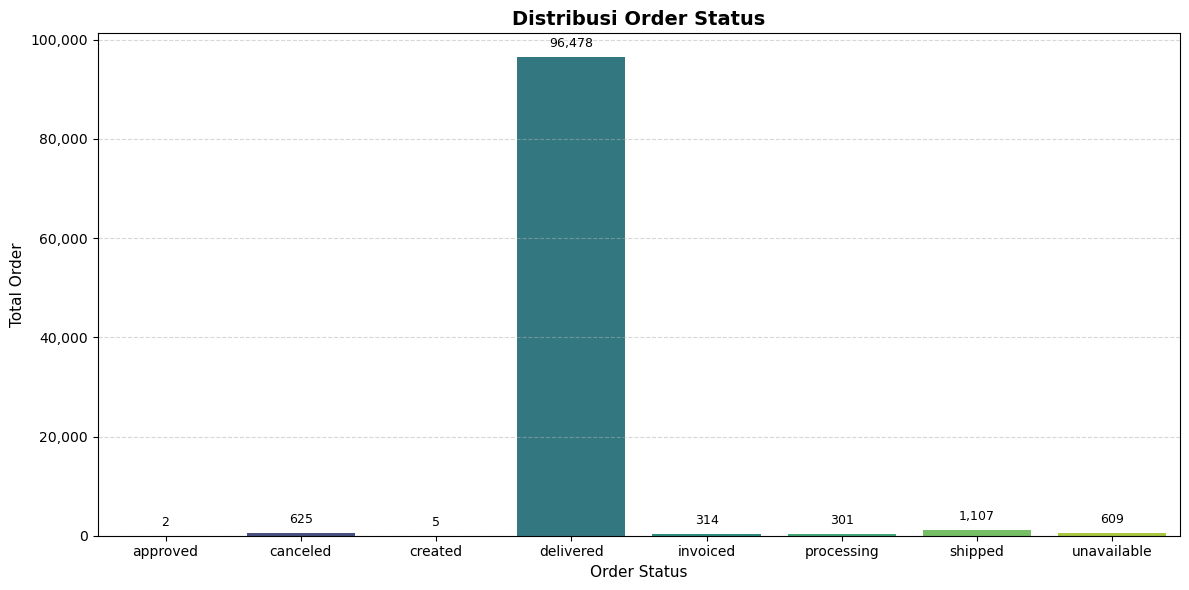

In [26]:

plt.figure(figsize=(12, 6))

# 2. Membuat Vertical Bar Plot dengan Gradient Warna (Palette)
ax = sns.barplot(
    data=distribution_order_status,
    x='order_status',              
    y='Total Order',  
    palette='viridis',        # Menggunakan palette gradient (contoh: biru dari gelap ke terang)
    hue='order_status',       # Ditambahkan agar palette berfungsi optimal di Seaborn terbaru
    legend=False              # Menyembunyikan legend karena hue hanya digunakan untuk warna
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}',      
        padding=5,          
        fontsize=9
    )

# 4. Mengatasi format angka pada sumbu Y
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 5. Judul dan Label Sumbu
plt.title('Distribusi Order Status', fontsize=14, fontweight='bold')
plt.xlabel('Order Status', fontsize=11)
plt.ylabel('Total Order', fontsize=11)

# 6. Grid disesuaikan menjadi horizontal (sumbu Y)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout() 
plt.show()

### KEY INSIGHT

Order dengan status delivered mendominasi distribusi order dengan total 96.478 order, jauh lebih tinggi dibandingkan status shipped yang berada di posisi berikutnya dengan 1.107 order.

### 2. Berapa rata-rata waktu dari order_purchase sampai order_approved per status?

In [27]:
avg_time = order[['order_id','order_status','order_purchase_timestamp','order_approved_at']]
avg_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  99441 non-null  object        
 1   order_status              99441 non-null  object        
 2   order_purchase_timestamp  99441 non-null  datetime64[ns]
 3   order_approved_at         99281 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 3.0+ MB


In [28]:
avg_time.isna().sum()

order_id                      0
order_status                  0
order_purchase_timestamp      0
order_approved_at           160
dtype: int64

**DATA QUALITY NOTE**

Pada data Q2 ditemukan **160 missing value pada `order_approved_at`** dari kolom yang digunakan dalam analisis. Karena `order_approved_at` merupakan variabel utama untuk menghitung waktu antara `order_purchase_timestamp` dan proses approval order, data dengan nilai yang kosong tidak dapat digunakan dalam perhitungan. Oleh karena itu, **160 order tersebut dikeluarkan dari analisis Q2**.


In [29]:
avg_time = avg_time.dropna()

In [30]:
avg_time.isna().sum()

order_id                    0
order_status                0
order_purchase_timestamp    0
order_approved_at           0
dtype: int64

In [31]:
avg_time['time_purchase_to_approve'] = ((avg_time['order_approved_at'] - avg_time['order_purchase_timestamp']).dt.total_seconds() / 86400)

In [32]:
avg_time_order_status = avg_time.groupby('order_status')[ 'time_purchase_to_approve'].mean().reset_index()
avg_time_order_status

,order_status,time_purchase_to_approve
0,approved,2.902483
1,canceled,0.611051
2,delivered,0.428199
3,invoiced,0.376512
4,processing,0.714710
5,shipped,0.488917
6,unavailable,1.016199


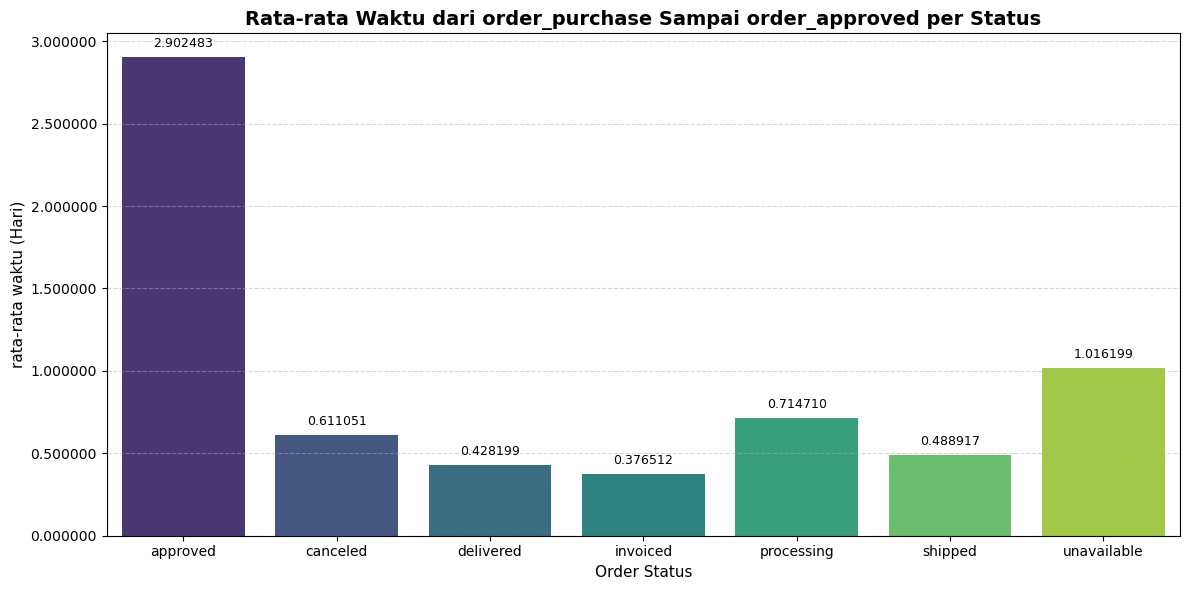

In [33]:

plt.figure(figsize=(12, 6))

# 2. Membuat Vertical Bar Plot dengan Gradient Warna (Palette)
ax = sns.barplot(
    data=avg_time_order_status,
    x='order_status',              
    y='time_purchase_to_approve',  
    palette='viridis',        # Menggunakan palette gradient (contoh: biru dari gelap ke terang)
    hue='order_status',       # Ditambahkan agar palette berfungsi optimal di Seaborn terbaru
    legend=False              # Menyembunyikan legend karena hue hanya digunakan untuk warna
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.6f}',      
        padding=5,          
        fontsize=9
    )

# 4. Mengatasi format angka pada sumbu Y
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.6f}'))

# 5. Judul dan Label Sumbu
plt.title('Rata-rata Waktu dari order_purchase Sampai order_approved per Status', fontsize=14, fontweight='bold')
plt.xlabel('Order Status', fontsize=11)
plt.ylabel('rata-rata waktu (Hari)', fontsize=11)

# 6. Grid disesuaikan menjadi horizontal (sumbu Y)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout() 
plt.show()

#### KEY INSIGHT 

Order dengan status approved memiliki rata-rata waktu purchase-to-approve tertinggi sebesar 2,90 hari, sedangkan status invoiced memiliki waktu terendah sebesar 0,38 hari. Sebagian besar status order lainnya memiliki rata-rata waktu approval di bawah 1 hari.

### 3. Berapa persentase item yang dibatalkan dan kategori produk apa yang paling banyak mengalami pembatalan?

In [34]:
# TRANSLATE PRODUCT CATEGORY NAME
translate = name_translate_product.set_index('product_category_name')['product_category_name_english']
product['product_category_name'] = product['product_category_name'].map(translate).fillna(product['product_category_name'])

In [35]:
# MENGUBAH DI TABEL PRODUCT NAMA PRODUCT YANG NULL MENJADI UNKOWN + 5 HURUF TERAKHIR PRODUCT ID 
product['product_category_name'] = product['product_category_name'].fillna(
    'unkown_' + product['product_id'].str[-5:])

**DATA QUALITY NOTE**

Pada kolom `product_category_name` ditemukan nilai null. Karena produk dengan kategori yang tidak tersedia tetap memiliki `product_id` dan masih relevan untuk analisis, data tersebut tidak dikeluarkan. Nilai null kemudian ditangani dengan membuat label **`unkown_` + 5 karakter terakhir dari `product_id`** sebagai identifikasi kategori yang tidak diketahui.


In [36]:
#JOIN TABEL ORDER DAN ORDER_ITEMS
orders_items = pd.merge(
    left = order_items,
    right = order,
    how = 'inner',
    on = 'order_id'
)

In [37]:
#JOIN TABEL ORDER, ORDER_ITEMS DAN PRODUCT
orders_items_products = pd.merge(
    left = orders_items,
    right = product,
    how = 'left',
    on = 'product_id'
)

In [38]:
#MENGAMBIL FEATURE YANG DIBUTUHKAN UNTUK ANALISIS DATA
orders_items_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  object        
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   customer_id                    112650 non-null  object        
 8   order_status                   112650 non-null  object        
 9   order_purchase_timestamp       112650 non-null  datetime64[ns]
 10  order_approved_at              112635 non-null  datetime64[ns]
 11  

In [39]:
# MELAKUKAN FILTER TABEL ORDER DENGAN ORDER_STATUS = CANCELED
orders_items_products = orders_items_products[orders_items_products['order_status'] == 'canceled']

In [40]:
orders_items_products = orders_items_products[['order_id','order_item_id','product_category_name']]
orders_items_products

,order_id,order_item_id,product_category_name
84,00310b0c75bb13015ec4d82d341865a4,1,housewares
270,00ae7a8b4936674ebb701d4a23719a79,1,auto
422,00ff0cf5583758e6964723e42f111bf4,1,health_beauty
543,013e9c654a339d80b53513da3c1ea437,1,housewares
558,0148d3df00cebda592d4e5f966e300cc,1,housewares
...,...,...,...
110535,fb265b2dc558a56445dfc48f8224e201,1,health_beauty
111019,fc3c882665c98c9b737a7b1b3aa6c553,1,bed_bath_table
111703,fdbbb1715d0c62c714e2a8178b95dd54,1,health_beauty
112073,fe9aa3b22b4d65ccbaffb57984bc12fb,1,toys


In [41]:
cancel_item = orders_items_products.groupby('product_category_name')['order_item_id'].count().reset_index()

In [42]:
cancel_item.sort_values(by='order_item_id', ascending=False).head(10)

,product_category_name,order_item_id
43,sports_leisure,51
32,housewares,49
8,computers_accessories,46
28,health_beauty,36
25,furniture_decor,36
46,toys,34
3,auto,30
61,watches_gifts,21
4,baby,20
27,garden_tools,19


In [43]:
#MENGGANTI NAMA KOLOM
cancel_item = cancel_item.rename(columns={
    'order_item_id': 'Total Order'
    }
)                                 
cancel_item

,product_category_name,Total Order
0,air_conditioning,2
1,art,1
2,audio,1
3,auto,30
4,baby,20
...,...,...
57,unkown_bc2fa,1
58,unkown_c6105,1
59,unkown_e0447,1
60,unkown_fa494,1


In [44]:
#MEMBUAT CANCELED_ITEM_PCT
grand_total = cancel_item['Total Order'].sum()
cancel_item['canceled_item_pct'] = cancel_item['Total Order'] / grand_total  * 100
cancel_item.sort_values(by='Total Order', ascending=False).head(10)

,product_category_name,Total Order,canceled_item_pct
43,sports_leisure,51,9.409594
32,housewares,49,9.040590
8,computers_accessories,46,8.487085
28,health_beauty,36,6.642066
25,furniture_decor,36,6.642066
46,toys,34,6.273063
3,auto,30,5.535055
61,watches_gifts,21,3.874539
4,baby,20,3.690037
27,garden_tools,19,3.505535


C:\Users\adien\AppData\Local\Temp\ipykernel_12484\2859341854.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


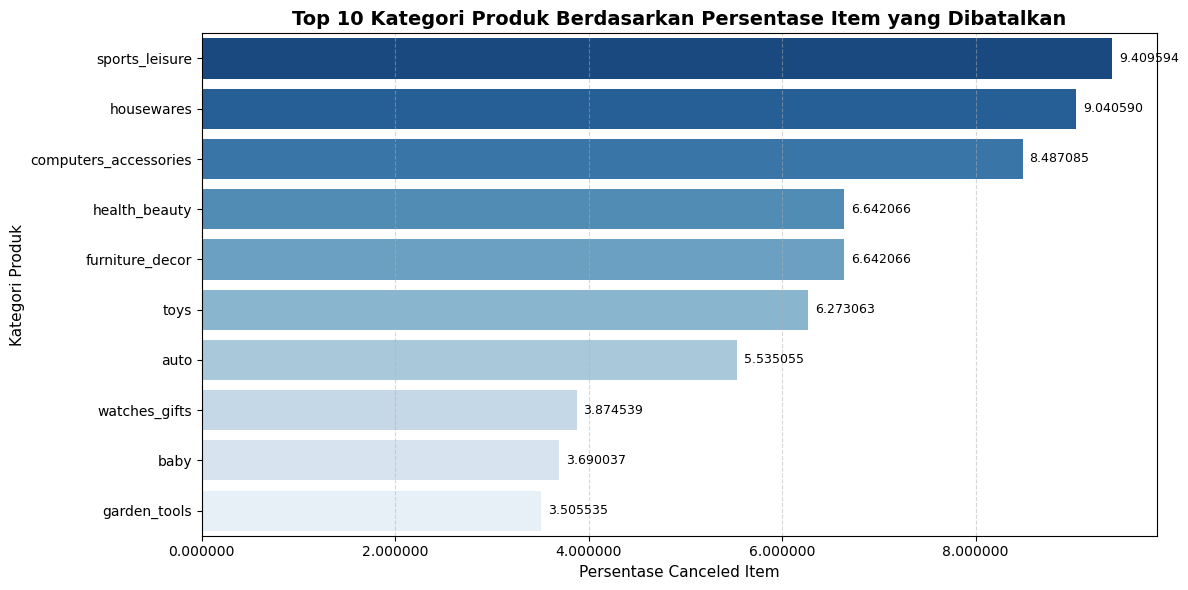

In [45]:
# 1. Ambil 10 data teratas (diurutkan dari terbesar)
# Sesuaikan 'Total Revenue' dan 'product_category_name' dengan nama kolom Anda
top_10 = cancel_item.sort_values(by='canceled_item_pct', ascending=False).head(10)

# 2. Buat kanvas plot
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=top_10,
    x='canceled_item_pct',            # Sumbu X (Angka)
    y='product_category_name',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.6f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.6f}'))

# 6. Judul dan Label Sumbu
plt.title('Top 10 Kategori Produk Berdasarkan Persentase Item yang Dibatalkan', fontsize=14, fontweight='bold')
plt.xlabel('Persentase Canceled Item', fontsize=11)
plt.ylabel('Kategori Produk', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

#### KEY INSIGHT 

Kategori sports_leisure memiliki kontribusi item yang dibatalkan tertinggi sebesar 9,41% (51 item), diikuti oleh housewares sebesar 9,04% (49 item).

## KEY FINDINGS

1. Order dengan status delivered mendominasi distribusi order dengan total 96.478 order, jauh lebih tinggi dibandingkan status shipped yang berada di posisi berikutnya dengan 1.107 order.
2. Order dengan status approved memiliki rata-rata waktu purchase-to-approve tertinggi sebesar 2,90 hari, sedangkan status invoiced memiliki waktu terendah sebesar 0,38 hari. Sebagian besar status order lainnya memiliki rata-rata waktu approval di bawah 1 hari.
3. Kategori sports_leisure memiliki kontribusi item yang dibatalkan tertinggi sebesar 9,41% (51 item), diikuti oleh housewares sebesar 9,04% (49 item).

## BUSINESS IMPLICATIONS

1. Bisnis dapat mempertahankan proses fulfillment yang berjalan dan menggunakan distribusi status order sebagai indikator monitoring operasional.
2. Bisnis dapat melakukan monitoring terhadap proses approval untuk mengidentifikasi potensi bottleneck dan mengevaluasi apakah proses verifikasi atau approval dapat dipercepat.
3. Bisnis dapat melakukan evaluasi lebih lanjut terhadap proses order pada kedua kategori tersebut, seperti ketersediaan produk, proses fulfillment, atau alasan pembatalan, untuk mengidentifikasi faktor yang berkaitan dengan tingginya pembatalan.